# Problem 2
Dataset Healthcare Time Series (e.g., ECG Classification): ECG200 from UCR Archive – This dataset contains
200 electrocardiogram sequences each of length 96, labeled as either normal or arrhythmia. We will use 100 series
for training and 100 for testing (balanced classes). The goal is to classify heartbeats using learned representations.
Alternate options: Another possible dataset is the PhysioNet MIT-BIH Arrhythmia ECG dataset (longer heart-
beat signals with multiple classes), or a wearable sensor time series dataset for activity recognition (where each series is an acceleration signal labeled by activity). Ensure whichever dataset you choose, it has a clear train/test
split and labels for a supervised evaluation. (The ECG200 is convenient and small; if a larger challenge is desired,
choose a more complex dataset but be mindful of training time for representation learning models.)

TS2Vec implementation: `zhihanyue/ts2vec`  
T-Rep implementation: `Let-it-Care/T-Rep`


In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device {DEVICE}")

device cpu


## A.
Select Dataset: Choose a real-world healthcare time series dataset suitable for a classification or
anomaly detection task. Examples: an ECG dataset where each time series is labeled as normal or ar-
rhythmia (e.g., the ECG200 dataset from the UCR archive, which contains 200 heartbeat time series for
two classes), or a clinical dataset where sequences of patient vital signs are labeled by outcome. Ensure
the data is preprocessed (e.g., each series has the same length or you truncate/zero-pad as needed, and
consider normalization).

ECG200 train shape: (100, 96, 1); test shape: (100, 96, 1)
Train class counts: {0: 31, 1: 69}
Test class counts:  {0: 36, 1: 64}
Label mapping: {0: 'class -1', 1: 'class 1'}


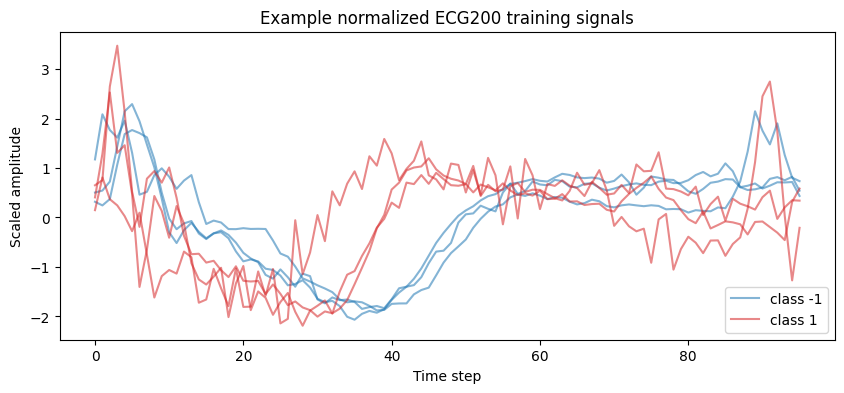

In [2]:
LIST8_DIR = Path.cwd()
TS2VEC_REPO = LIST8_DIR / "external" / "ts2vec_official"
TREP_REPO = LIST8_DIR / "external" / "t_rep_official"
ECG200_DIR = TS2VEC_REPO / "datasets" / "UCR" / "ECG200"

train_path = ECG200_DIR / "ECG200_TRAIN.tsv"
test_path = ECG200_DIR / "ECG200_TEST.tsv"

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None)

raw_train_labels = train_df.iloc[:, 0].to_numpy()
raw_test_labels = test_df.iloc[:, 0].to_numpy()
label_values = np.sort(np.unique(raw_train_labels))
label_to_id = {label: idx for idx, label in enumerate(label_values)}
id_to_label = {idx: f"class {label:g}" for label, idx in label_to_id.items()}

y_train = np.vectorize(label_to_id.get)(raw_train_labels)
y_test = np.vectorize(label_to_id.get)(raw_test_labels)

X_train_raw = train_df.iloc[:, 1:].to_numpy(dtype=np.float32)[..., None]
X_test_raw = test_df.iloc[:, 1:].to_numpy(dtype=np.float32)[..., None]

scaler = StandardScaler().fit(X_train_raw.reshape(-1, 1))
X_train = scaler.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape).astype(np.float32)
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape).astype(np.float32)

print(f"ECG200 train shape: {X_train.shape}; test shape: {X_test.shape}")
print(f"Train class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class counts:  {dict(zip(*np.unique(y_test, return_counts=True)))}")
print(f"Label mapping: {id_to_label}")

colors = ["tab:blue", "tab:red"]

plt.figure(figsize=(10, 4))
for class_id, color in zip(np.unique(y_train), colors):
    idx = np.where(y_train == class_id)[0][:3]
    for line_number, i in enumerate(idx):
        plt.plot(X_train[i, :, 0], color=color, alpha=0.55, label=id_to_label[class_id] if line_number == 0 else None)
plt.title("Example normalized ECG200 training signals")
plt.xlabel("Time step")
plt.ylabel("Scaled amplitude")
plt.legend()
plt.show()

## B. 
Install and Configure Models: Use official or existing implementations for TS2Vec and T-Rep (see
the notebooks presented during the lecture). Make sure you understand the input format each expects
(TS2Vec may require creating augmented views; T-Rep’s API might handle that internally). If needed, use
a smaller subset of data to tune any hyperparameters due to time constraints

In [3]:
for name in [m for m in sys.modules if m in {"models", "utils", "datautils", "ts2vec", "trep"} or m.startswith("models.")]:
    sys.modules.pop(name, None)

sys.path.insert(0, str(TS2VEC_REPO.resolve()))
from ts2vec import TS2Vec
sys.path.pop(0)

for name in [m for m in sys.modules if m in {"models", "utils", "datautils", "trep"} or m.startswith("models.")]:
    sys.modules.pop(name, None)

sys.path.insert(0, str(TREP_REPO.resolve()))
from trep import TRep
sys.path.pop(0)

TS2VEC_CONFIG = dict(
    input_dims=1,
    output_dims=64,
    hidden_dims=32,
    depth=4,
    device=DEVICE,
    batch_size=16,
    lr=1e-3
)
TREP_CONFIG = dict(
    input_dims=1,
    output_dims=64,
    hidden_dims=32,
    time_embedding="t2v_sin",
    time_embedding_dim=16,
    depth=4,
    device=DEVICE,
    batch_size=16,
    lr=1e-3,
)

print("TS2Vec config:", TS2VEC_CONFIG)
print("T-Rep config:", TREP_CONFIG)

TS2Vec config: {'input_dims': 1, 'output_dims': 64, 'hidden_dims': 32, 'depth': 4, 'device': 'cpu', 'batch_size': 16, 'lr': 0.001}
T-Rep config: {'input_dims': 1, 'output_dims': 64, 'hidden_dims': 32, 'time_embedding': 't2v_sin', 'time_embedding_dim': 16, 'depth': 4, 'device': 'cpu', 'batch_size': 16, 'lr': 0.001}


## C. 
Unsupervised Training: Train the TS2Vec model on the training portion of your dataset to learn
representations. This involves feeding the raw time series (without labels) into TS2Vec’s training routine.
Similarly, train T-Rep on the same training data (T-Rep will learn time-step level embeddings and an en-
coder). Both models will output some form of encoded representation for each time series or each time step.
For consistency, decide on the representation you will extract for the downstream task. For example, you
might use instance-level embeddings (one vector per entire time series) by aggregating TS2Vec’s timestamp
embeddings (e.g., average or using the final timestamp) and using T-Rep’s output for the final timestamp
(or an average as well).

In [4]:
N_EPOCHS = 20

training_logs = {}
training_rows = []

start = time.perf_counter()
ts2vec = TS2Vec(**TS2VEC_CONFIG)
ts2vec_loss = ts2vec.fit(X_train, n_epochs=N_EPOCHS)
ts2vec_time = time.perf_counter() - start
training_logs["TS2Vec"] = ts2vec_loss
training_rows.append(
    {
        "model": "TS2Vec",
        "repr_dim": TS2VEC_CONFIG["output_dims"] if "output_dims" in TS2VEC_CONFIG else None,
        "epochs": len(ts2vec_loss),
        "training_time_s": ts2vec_time,
        "final_ssl_loss": ts2vec_loss[-1],
    }
)

start = time.perf_counter()
trep = TRep(**TREP_CONFIG)
trep_loss = trep.fit(X_train, n_epochs=N_EPOCHS)
trep_time = time.perf_counter() - start
training_logs["T-Rep"] = trep_loss
training_rows.append(
    {
        "model": "T-Rep",
        "repr_dim": TREP_CONFIG["output_dims"] if "output_dims" in TREP_CONFIG else None,
        "epochs": len(trep_loss),
        "training_time_s": trep_time,
        "final_ssl_loss": trep_loss[-1],
    }
)

training_summary = pd.DataFrame(training_rows)
training_summary

,model,repr_dim,epochs,training_time_s,final_ssl_loss
0,TS2Vec,64,20,4.497925,1.966724
1,T-Rep,64,20,6.625384,1.036755


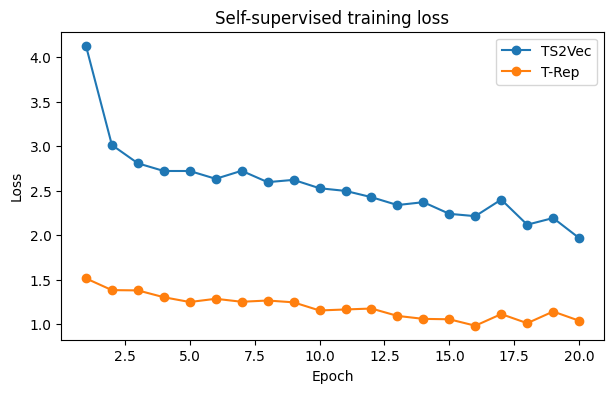

In [5]:
plt.figure(figsize=(7, 4))
for name, losses in training_logs.items():
    plt.plot(np.arange(1, len(losses) + 1), losses, marker="o", label=name)
plt.title("Self-supervised training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## D.
Obtain Representations: After training, use the learned models to encode all training and test samples
into representation vectors. For TS2Vec, this might mean passing each time series (or sub-sequence) through
the trained network to get a sequence of embeddings, then pooling or selecting the relevant part. For T-
Rep, you can use trep.encode(data) as in the provided example to get an array of representations. Ensure
the dimension of these representations is noted (e.g., TS2Vec default might be 128 or 256 per timestamp,
T-Rep default output dims=128 unless changed).

In [6]:
ts2vec_train_repr = ts2vec.encode(X_train, encoding_window="full_series")
ts2vec_test_repr = ts2vec.encode(X_test, encoding_window="full_series")

trep_train_repr = trep.encode(X_train, encoding_window="full_series")
trep_test_repr = trep.encode(X_test, encoding_window="full_series")

representation_shapes = pd.DataFrame(
    [
        {"model": "TS2Vec", "train_repr_shape": ts2vec_train_repr.shape, "test_repr_shape": ts2vec_test_repr.shape},
        {"model": "T-Rep", "train_repr_shape": trep_train_repr.shape, "test_repr_shape": trep_test_repr.shape},
    ]
)
representation_shapes

,model,train_repr_shape,test_repr_shape
0,TS2Vec,"(100, 64)","(100, 64)"
1,T-Rep,"(100, 64)","(100, 64)"


## E. 
Downstream Classification Task: Using the labeled data, train a simple classifier on top of the
learned representations. For example, train a Logistic Regression or Support Vector Machine (SVM) using
the instance-level representation of each time series as features to predict its class. (In the ECG example,
each heartbeat time series is represented by a learned vector, and you predict “normal” vs “abnormal”).
Do this for both TS2Vec-derived embeddings and T-Rep embeddings separately. Evaluate the classification
accuracy (or F1-score, etc., depending on the problem) on the test set for each case. If the dataset has a
class imbalance, ensure you use appropriate metrics or techniques.

In [7]:
def fit_evaluate_classifier(name, train_features, test_features):
    clf = LogisticRegression(max_iter=3000, class_weight="balanced")
    clf.fit(train_features, y_train)
    pred = clf.predict(test_features)
    return clf, {
        "features": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),    # avg of positive and negative f1
        "positive_f1": f1_score(y_test, pred),
    }


classifiers = {}
metric_rows = []

for name, train_repr, test_repr in [
    ("TS2Vec representation", ts2vec_train_repr, ts2vec_test_repr),
    ("T-Rep representation", trep_train_repr, trep_test_repr),
]:
    clf, metrics = fit_evaluate_classifier(name, train_repr, test_repr)
    classifiers[name] = clf
    metric_rows.append(metrics)

ssl_classification_summary = pd.DataFrame(metric_rows).sort_values("balanced_accuracy", ascending=False)
ssl_classification_summary

,features,accuracy,balanced_accuracy,macro_f1,positive_f1
0,TS2Vec representation,0.80,0.795139,0.787776,0.83871
1,T-Rep representation,0.76,0.739583,0.739583,0.81250


## F.
Baseline Comparison: For context, also evaluate a baseline approach. For instance, use raw features
or a simpler representation: you could take the raw time series (normalized) and flatten it or use basic
statistics (mean, std, etc.) as features for the same classifier. Alternatively, train a fully supervised deep
learning model (like a small CNN or RNN) directly on the labeled data for comparison. The goal is to
see how the self-supervised representations stack up against a naive representation or a fully supervised
approach with the same amount of labeled data.

In [8]:
def statistical_features(x):
    signal = x[:, :, 0]
    time_index = np.arange(signal.shape[1], dtype=np.float32)
    centered_time = time_index - time_index.mean()
    slopes = ((signal - signal.mean(axis=1, keepdims=True)) @ centered_time) / np.sum(centered_time ** 2)
    return np.column_stack(
        [
            signal.mean(axis=1),
            signal.std(axis=1),
            signal.min(axis=1),
            signal.max(axis=1),
            np.median(signal, axis=1),
            np.percentile(signal, 25, axis=1),
            np.percentile(signal, 75, axis=1),
            slopes,
        ]
    )


baseline_feature_sets = {
    "Raw flattened waveform": (X_train.reshape(len(X_train), -1), X_test.reshape(len(X_test), -1)),
    "Basic statistics": (statistical_features(X_train), statistical_features(X_test)),
}

for name, (train_features, test_features) in baseline_feature_sets.items():
    clf, metrics = fit_evaluate_classifier(name, train_features, test_features)
    classifiers[name] = clf
    metric_rows.append(metrics)

classification_summary = pd.DataFrame(metric_rows).sort_values("balanced_accuracy", ascending=False)
classification_summary

,features,accuracy,balanced_accuracy,macro_f1,positive_f1
2,Raw flattened waveform,0.82,0.822917,0.810845,0.852459
0,TS2Vec representation,0.80,0.795139,0.787776,0.838710
3,Basic statistics,0.78,0.773438,0.766553,0.822581
1,T-Rep representation,0.76,0.739583,0.739583,0.812500


## G. 
Analysis of Representations: Analyze the quality of the learned representations. Perform the follow-
ing:
- Visualization: Use a dimensionality reduction technique (e.g., t-SNE or PCA) to project the learned
representations of the test set into 2D. Create a scatter plot where each point is a time series in the
embedding space, colored by its true label. Do this for TS2Vec and T-Rep embeddings. Discuss any
observable clustering – e.g., “We see two distinct clusters for the two classes with T-Rep, indicating
good class separation, whereas TS2Vec embeddings overlap more” or vice versa.
- Nearest Neighbors: Pick a few example time series and find their nearest neighbors in the represen-
tation space (using Euclidean distance or cosine similarity). Check if those neighbors share the same
class or similar characteristics. This can qualitatively show whether the embedding is grouping similar
time series together meaningfully.
- Robustness test: If time permits, test robustness to missing data: e.g., remove or mask out a portion
of the time series and see how the representations change or if the models can still encode them well
(this relates to T-Rep’s claim of resilience to missing data

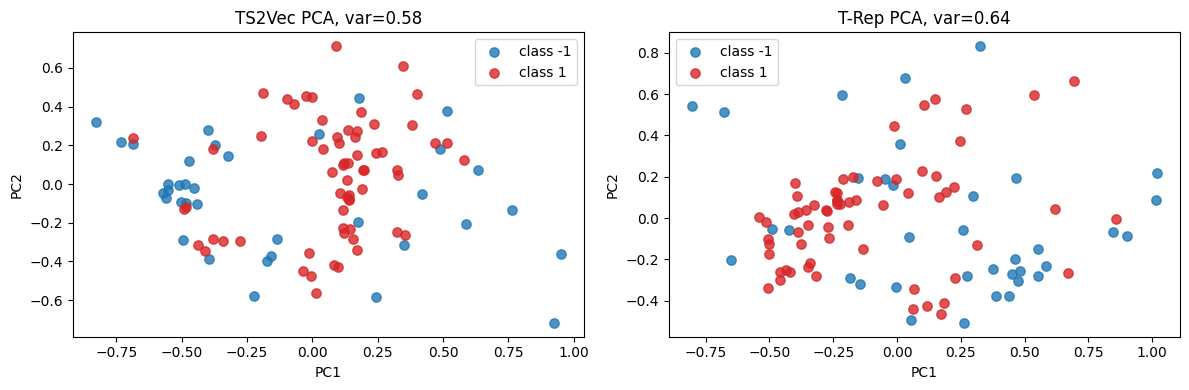

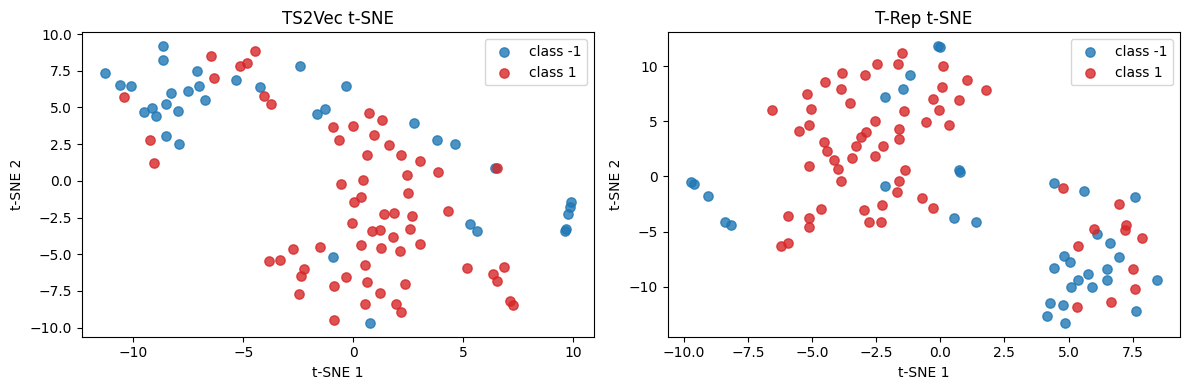

,model,centroid_to_spread_ratio
1,T-Rep,0.645269
0,TS2Vec,0.532998


In [9]:
representation_sets = {
    "TS2Vec": ts2vec_test_repr,
    "T-Rep": trep_test_repr,
}

pca_coords = {}
pca_variance = {}
for name, repr_values in representation_sets.items():
    pca = PCA(n_components=2)
    pca_coords[name] = pca.fit_transform(repr_values)
    pca_variance[name] = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(12, 4))
for plot_number, (name, coords) in enumerate(pca_coords.items(), start=1):
    plt.subplot(1, 2, plot_number)
    for class_id, color in zip(np.unique(y_test), colors):
        mask = y_test == class_id
        plt.scatter(coords[mask, 0], coords[mask, 1], color=color, s=45, alpha=0.8, label=id_to_label[class_id])
    plt.title(f"{name} PCA, var={pca_variance[name]:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
plt.tight_layout()
plt.show()

tsne_coords = {}
for name, repr_values in representation_sets.items():
    tsne_coords[name] = TSNE(n_components=2, perplexity=20).fit_transform(repr_values)

plt.figure(figsize=(12, 4))
for plot_number, (name, coords) in enumerate(tsne_coords.items(), start=1):
    plt.subplot(1, 2, plot_number)
    for class_id, color in zip(np.unique(y_test), colors):
        mask = y_test == class_id
        plt.scatter(coords[mask, 0], coords[mask, 1], color=color, s=45, alpha=0.8, label=id_to_label[class_id])
    plt.title(f"{name} t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
plt.tight_layout()
plt.show()

separation_rows = []
for name, repr_values in representation_sets.items():
    classes = np.unique(y_test)
    centroids = np.vstack([repr_values[y_test == cls].mean(axis=0) for cls in classes])
    inter = np.linalg.norm(centroids[0] - centroids[1])
    spreads = []
    for cls, centroid in zip(classes, centroids):
        spreads.append(np.linalg.norm(repr_values[y_test == cls] - centroid, axis=1).mean())
    separation_rows.append({"model": name, "centroid_to_spread_ratio": inter / np.mean(spreads)})

separation_summary = pd.DataFrame(separation_rows).sort_values("centroid_to_spread_ratio", ascending=False)
separation_summary

#### nearest neighbors

In [10]:
selected_queries = []
for class_id in np.unique(y_test):
    selected_queries.extend(np.where(y_test == class_id)[0][:2].tolist())

nn_rows = []
for name, repr_values in representation_sets.items():
    nbrs = NearestNeighbors(n_neighbors=4, metric="euclidean")
    nbrs.fit(repr_values)
    distances, indices = nbrs.kneighbors(repr_values[selected_queries])
    for query_id, dist_row, index_row in zip(selected_queries, distances, indices):
        for distance, neighbor_id in zip(dist_row[1:], index_row[1:]):
            nn_rows.append(
                {
                    "model": name,
                    "query_id": query_id,
                    "query_label": id_to_label[int(y_test[query_id])],
                    "neighbor_id": int(neighbor_id),
                    "neighbor_label": id_to_label[int(y_test[neighbor_id])],
                    "distance": float(distance),
                    "same_class": bool(y_test[query_id] == y_test[neighbor_id]),
                }
            )

nn_summary = pd.DataFrame(nn_rows)
nn_accuracy = nn_summary.groupby("model")["same_class"].mean().rename("fraction_same_class_neighbors").reset_index()

nn_accuracy

,model,fraction_same_class_neighbors
0,T-Rep,0.916667
1,TS2Vec,0.916667


#### missing data

In [11]:
N_MASK_TESTS = 10
mask_width = 20
robustness_rows = []

for test_id in range(N_MASK_TESTS):
    mask_start = np.random.randint(0, X_test.shape[1] - mask_width + 1)
    X_test_masked = X_test.copy()
    X_test_masked[:, mask_start : mask_start + mask_width, :] = np.nan

    ts2vec_test_masked_repr = ts2vec.encode(X_test_masked, encoding_window="full_series")
    trep_test_masked_repr = trep.encode(X_test_masked, encoding_window="full_series")

    for clean_name, clean_repr, masked_repr in [
        ("TS2Vec representation", ts2vec_test_repr, ts2vec_test_masked_repr),
        ("T-Rep representation", trep_test_repr, trep_test_masked_repr),
    ]:
        clf = classifiers[clean_name]
        pred = clf.predict(masked_repr)
        robustness_rows.append(
            {
                "features": clean_name,
                "test_id": test_id,
                "mask_start": mask_start,
                "accuracy": accuracy_score(y_test, pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "macro_f1": f1_score(y_test, pred, average="macro"),
                "positive_f1": f1_score(y_test, pred),
            }
        )

robustness_results = pd.DataFrame(robustness_rows)
robustness_summary = robustness_results.groupby("features")[["accuracy", "balanced_accuracy", "macro_f1", "positive_f1"]].mean()
robustness_summary = robustness_summary.sort_values("balanced_accuracy", ascending=False)
robustness_summary

,accuracy,balanced_accuracy,macro_f1,positive_f1
features,,,,
TS2Vec representation,0.695,0.729514,0.682675,0.687113
T-Rep representation,0.676,0.688542,0.649193,0.659416
